# LeetCode #161: One Edit Distance

https://leetcode.com/problems/one-edit-distance/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Edit Distance DP** | $O(m \times n)$ | $O(m \times n)$ |
| **Optimal: One Pass** | $O(n)$ | $O(1)$ |

---

## Understanding the Methods

### Edit Distance DP
Compute the full edit distance using dynamic programming and check if it equals 1. This works but is overkill — $O(mn)$ time and space for a problem that only needs $O(n)$.

### Optimal: One Pass ★
Ensure `s` is the shorter string (swap if needed). If the length difference is more than 1, return false.

Scan both strings simultaneously:
- When a mismatch is found:
  - If same length: both strings must match from the next character onward (replace operation).
  - If different length: the longer string must match the shorter from the current position onward (insert/delete operation).
- If no mismatch is found: return true only if the lengths differ by exactly 1 (the edit is appending/removing the last character).

**Key insight:** "Exactly one edit" means the strings cannot be equal — they must differ in exactly one operation.

**Constraints:**
* `0 <= s.length, t.length <= 10^4`
* Strings consist of lowercase letters, uppercase letters, and digits.

## Solutions

### C#

In [ ]:
public class Solution {
    public bool IsOneEditDistance(string s, string t) {
        if (s.Length > t.Length) return IsOneEditDistance(t, s);
        if (t.Length - s.Length > 1) return false;
        
        for (int i = 0; i < s.Length; i++) {
            if (s[i] != t[i]) {
                if (s.Length == t.Length) {
                    return s.Substring(i + 1) == t.Substring(i + 1);
                } else {
                    return s.Substring(i) == t.Substring(i + 1);
                }
            }
        }
        
        return s.Length + 1 == t.Length;
    }
}

### Python

In [ ]:
class Solution:
    def isOneEditDistance(self, s: str, t: str) -> bool:
        if len(s) > len(t):
            return self.isOneEditDistance(t, s)
        if len(t) - len(s) > 1:
            return False
        
        for i in range(len(s)):
            if s[i] != t[i]:
                if len(s) == len(t):
                    return s[i + 1:] == t[i + 1:]
                else:
                    return s[i:] == t[i + 1:]
        
        return len(s) + 1 == len(t)

### Go

In [ ]:
func isOneEditDistance(s string, t string) bool {
    if len(s) > len(t) {
        return isOneEditDistance(t, s)
    }
    if len(t)-len(s) > 1 {
        return false
    }
    
    for i := 0; i < len(s); i++ {
        if s[i] != t[i] {
            if len(s) == len(t) {
                return s[i+1:] == t[i+1:]
            }
            return s[i:] == t[i+1:]
        }
    }
    
    return len(s)+1 == len(t)
}

### Rust

In [ ]:
impl Solution {
    pub fn is_one_edit_distance(s: String, t: String) -> bool {
        let (s, t) = if s.len() <= t.len() {
            (s.as_bytes(), t.as_bytes())
        } else {
            (t.as_bytes(), s.as_bytes())
        };
        
        if t.len() - s.len() > 1 {
            return false;
        }
        
        for i in 0..s.len() {
            if s[i] != t[i] {
                if s.len() == t.len() {
                    return s[i + 1..] == t[i + 1..];
                } else {
                    return s[i..] == t[i + 1..];
                }
            }
        }
        
        s.len() + 1 == t.len()
    }
}

## Example Scenarios

1. **Common Case (Replace):** `s = "abc"`, `t = "adc"` $\Rightarrow$ `true`. Same-length strings. Index 0 matches, index 1 mismatches ('b' $\neq$ 'd'). Since lengths are equal, compare suffixes: `"c" == "c"`. Exactly one replace. $O(n)$ time.

2. **Slightly Complex (Insert in middle):** `s = "abcd"`, `t = "aXbcd"` $\Rightarrow$ `true`. Different lengths (4 vs 5, diff = 1). First mismatch at index 1: s[1]='b', t[1]='X'. Compare `s[1:]="bcd"` vs `t[2:]="bcd"` — they match. One insertion of 'X'. WHY tricky: mismatch in the middle exercises the "skip one in longer string" logic.

3. **Edge Case (Time):** `s = "a" * 9999 + "b"`, `t = "a" * 10000` (both length $10^4$) $\Rightarrow$ `true`. The scan matches 9999 characters before finding the mismatch at the last position. Worst case: must traverse the entire string. $O(10^4)$ comparisons before the mismatch is found.

4. **Edge Case (Space):** `s = "a" * 10000`, `t = "a" * 9999 + "b"` (both length $10^4$) $\Rightarrow$ `true`. The suffix comparison `s[i+1:]` creates a new string slice in copy-on-slice languages (Python). This allocates up to $O(n)$ extra memory. An index-based comparison avoids this. WHY tricky: the claimed $O(1)$ space only holds with string views, not copies.

5. **Almost-Impossible but Plausible:** `s = ""`, `t = ""` (both empty) $\Rightarrow$ `false`. The for-loop never executes. Final check: `len(s)+1 == len(t)` $\Rightarrow$ $1 == 0$ $\Rightarrow$ false. Identical strings require 0 edits, not 1. WHY tricky: boundary at $|s| = |t| = 0$. The constraint allows empty strings; returning true here is a common bug.

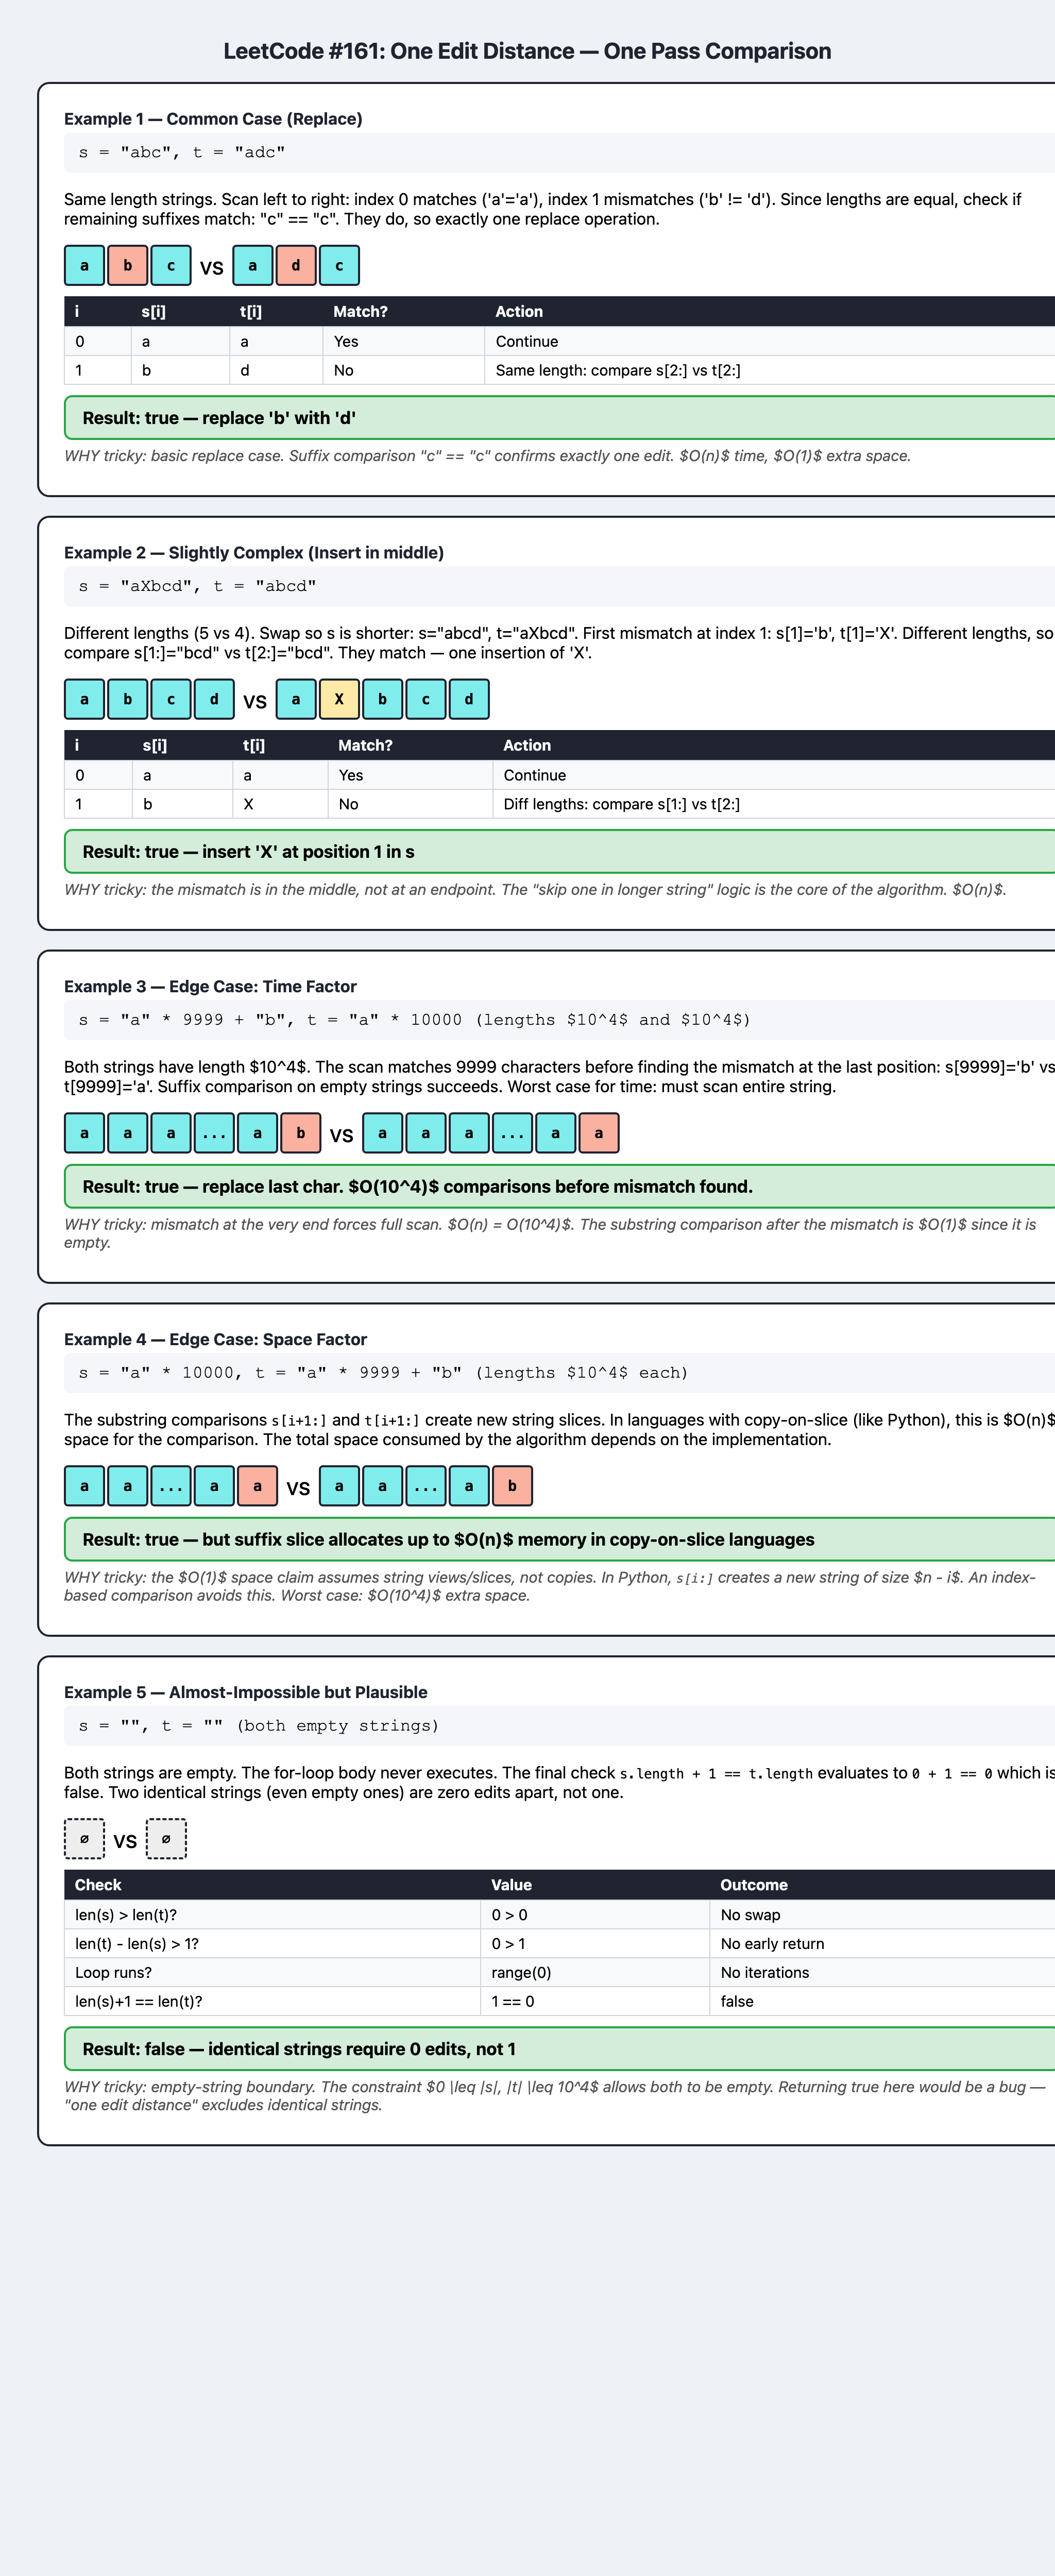